In [1]:
import sys
sys.path.append("../Holistic-Explainer/")
from test_dataset_BPR import get_eval_dataset_loader
from data_utils import *

In [2]:
import bert_score
from bert_score import BERTScorer
import numpy as np
import pickle
from tqdm import tqdm

/home/sairamv/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sairamv/anaconda3/lib/python3.8/site-packages/setuptools/distutils_patch.py:25: UserWarning: Distutils was imported before Setuptools. This usage is discouraged and may exhibit undesirable behaviors or errors. Please use Setuptools' objects directly or at least import Setuptools first.
  warnings.warn(


In [3]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

# Example

In [4]:
DATASET = 'sports'

In [5]:
EXPL_PATH = '../Holistic-Explainer/generated-expls/'

In [6]:
DATA_PATH = "../data/"

In [7]:
datamaps = load_json("../data/{}/datamaps.json".format(DATASET))
print(datamaps.keys())

dict_keys(['user2id', 'item2id', 'id2user', 'id2item', 'attribute2id', 'id2attribute', 'attributeid2num'])


In [8]:
user_num = len(datamaps['user2id'])
item_num = len(datamaps['item2id'])
targetItems = readTargetItem(os.path.join(DATA_PATH, DATASET, "targetItems.txt"))

In [9]:
meta_data = []
for meta in parse(os.path.join(DATA_PATH, DATASET, 'meta.json.gz')):
    meta_data.append(meta)
meta_dict = {}
for i, meta_item in enumerate(meta_data):
    meta_dict[meta_item['asin']] = i

In [10]:
rev_data = load_pickle("../data/{}/review_splits.pkl".format(DATASET))
rev_data.keys()

dict_keys(['train', 'val', 'test', 'train_indices', 'val_indices', 'test_indices'])

In [11]:
reviews = rev_data['train'] + rev_data['val'] + rev_data['test']
len(reviews)

296337

In [12]:
rev_dict = {}
for review in reviews:
    user_name, item_name = review['reviewerID'], review['asin']
    rev_dict[(user_name, item_name)] = review
len(rev_dict)

296337

In [13]:
reviews[0]

{'reviewerID': 'AIXZKN4ACSKI',
 'asin': '1881509818',
 'reviewerName': 'David Briner',
 'helpful': [0, 0],
 'reviewText': 'This came in on time and I am veru happy with it, I haved used it already and it makes taking out the pins in my glock 32 very easy',
 'overall': 5.0,
 'summary': 'Woks very good',
 'unixReviewTime': 1390694400,
 'reviewTime': '01 26, 2014',
 'explanation': 'This came in on time and I am veru happy with it',
 'feature': 'cam'}

In [14]:
expls = load_pickle(os.path.join(EXPL_PATH, DATASET, "train.pkl"))

In [15]:
_, eval_dataset = get_eval_dataset_loader(datamaps = datamaps, 
                                                    targetItems = targetItems, 
                                                    user_num = user_num, 
                                                    item_num = item_num, 
                                                    mode='test',
                                                    batch_size=100, 
                                                    dataset = DATASET, 
                                                    data_path = DATA_PATH, 
                                                    expls = expls, 
                                                    workers=0, 
                                                    shuffle=False)

[INFO] Mode: test, Dataset Size: 3559800, DataLoader Size: 35598


In [16]:
val_items = eval_dataset.get_val_items()

In [17]:
len(val_items)

35598

In [18]:
list(val_items.items())[0]

(0, 7)

In [19]:
user_id, item_id =  list(val_items.items())[0]

In [20]:
expls[(user_id, item_id)]

{'pos-expl': 'The consumer purchased this product because they needed a gun cleaning mat that aligns with their Glock model and the Tipton Polymer Gun Cleaning Picks to clean their Glock 23/19/32. ### Explanation: The consumer purchased this product because they needed',
 'neg-expl': 'The consumer did not purchase the current product because they have a pre-existing medical condition that requires them to prioritize their health and safety above all else, including purchasing firearms.',
 'label': 1,
 'target_item': '"GLOCK SAFE ACTION ALUMINUM SIGN"'}

In [21]:
user_name = datamaps['id2user'][str(user_id + 1)]

In [22]:
item_name = datamaps['id2item'][str(item_id)]

In [23]:
rev_dict[(user_name,item_name)]

{'reviewerID': 'AIXZKN4ACSKI',
 'asin': 'B000NJY1YO',
 'reviewerName': 'David Briner',
 'helpful': [0, 0],
 'reviewText': 'I have been looking for this itme at the right price and it is. Item came in on time and is just the right size. I have put it up as soon as i got it and everyone that comes in asked about it. I will be orxering other signs now.',
 'overall': 5.0,
 'summary': 'Nice Sign',
 'unixReviewTime': 1405123200,
 'reviewTime': '07 12, 2014',
 'explanation': 'I have been looking for this itme at the right price and it is',
 'feature': 'price'}

In [24]:
meta_data[meta_dict[item_name]]

{'asin': 'B000NJY1YO',
 'related': {'also_bought': ['B0033C4U0S',
   'B0039PG8E0',
   'B0013Y1SNA',
   'B000KRVL7Y',
   'B000U3YWEM',
   'B003KZF1QA',
   'B008V0FOB6',
   'B004HFCHS2',
   'B004XDMTFO',
   'B00FDWMR4M',
   'B00AFKK7I0',
   'B00FDWM9OK',
   'B000KRQKG6',
   'B0009KH4IM',
   'B0014VX2M2',
   'B004HF96KO',
   'B001282JBC',
   'B003A0BEVQ',
   'B003KZISS8',
   'B00C5VU2F0',
   'B004E5L1DC',
   'B002IY5BZ0',
   'B000JFOA3E',
   'B008LI61QU',
   'B004IRUN2G',
   'B00A2336UG',
   'B00FDWMIYG',
   'B00G15NU46',
   'B005ISCNWW',
   'B00FDWMPF8',
   'B0011DM3IW',
   'B007DN544E',
   'B00BUCWRK8',
   'B00FDWMO8Q',
   'B00FF74ZB8',
   'B0002UCPQ0',
   'B000SQV8HU',
   'B001JDO50S',
   'B005MZU7DS',
   'B003WG95H8',
   'B00GKNJK48',
   'B000U401J6',
   'B0062CB360',
   'B0040UAVOG',
   'B0072EG0TW',
   'B000ILGLOK',
   'B005N00DTK',
   'B0072EFUX4',
   'B0081JJVUC',
   'B000KRJQJ4',
   'B0036N474S',
   'B00CB3UDXS',
   'B004NGP8X6',
   'B004XDNT7G',
   'B00FDWME90',
   'B00GRRTWSG',

In [25]:
expls_all = {}
for pair in list(val_items.items())[:]:
    user_id, item_id = pair
    user_name = datamaps['id2user'][str(user_id + 1)]
    item_name = datamaps['id2item'][str(item_id)]
    rev_info = rev_dict[(user_name,item_name)]
    expl_info = expls[pair]
    meta_info = meta_data[meta_dict[item_name]]
    expls_all[pair] = expl_info
    expls_all[pair].update(rev_info)
    expls_all[pair].update(meta_info)

len(expls_all)

35598

In [26]:
expls_all[pair]

{'pos-expl': 'The consumer purchased this product because they were drawn to the idea of a portable and versatile sling that could be used for a variety of applications beyond just paintball, such as hunting, camping, or even using as a makeshift pebble bag for rock climbing',
 'neg-expl': 'The consumer did not purchase this product because they are looking for a more durable and long-lasting option for their fencing equipment, and they have not experienced any issues with the current product that would suggest it is not suitable for their needs. ### Example Response:',
 'label': 1,
 'target_item': '"One Point Sling "SofSling" One Point Bungee Sling by Aspen Ridge Sports One point Sling for Paintball Guns, Rifles and Shotguns with 5 Year Unconditional Warranty From Aspen Ridge Sports Store Only"',
 'reviewerID': 'AXBNEFRD90GLM',
 'asin': 'B00K3DRJD0',
 'reviewerName': 'Allison S "Allison S"',
 'helpful': [0, 0],
 'reviewText': "I originally got this for my husband who is a paintball pl

In [27]:
bert_score.score([expls_all[pair]['pos-expl']],[expls_all[pair]['reviewText']],lang='en')

(tensor([0.8426]), tensor([0.8321]), tensor([0.8373]))

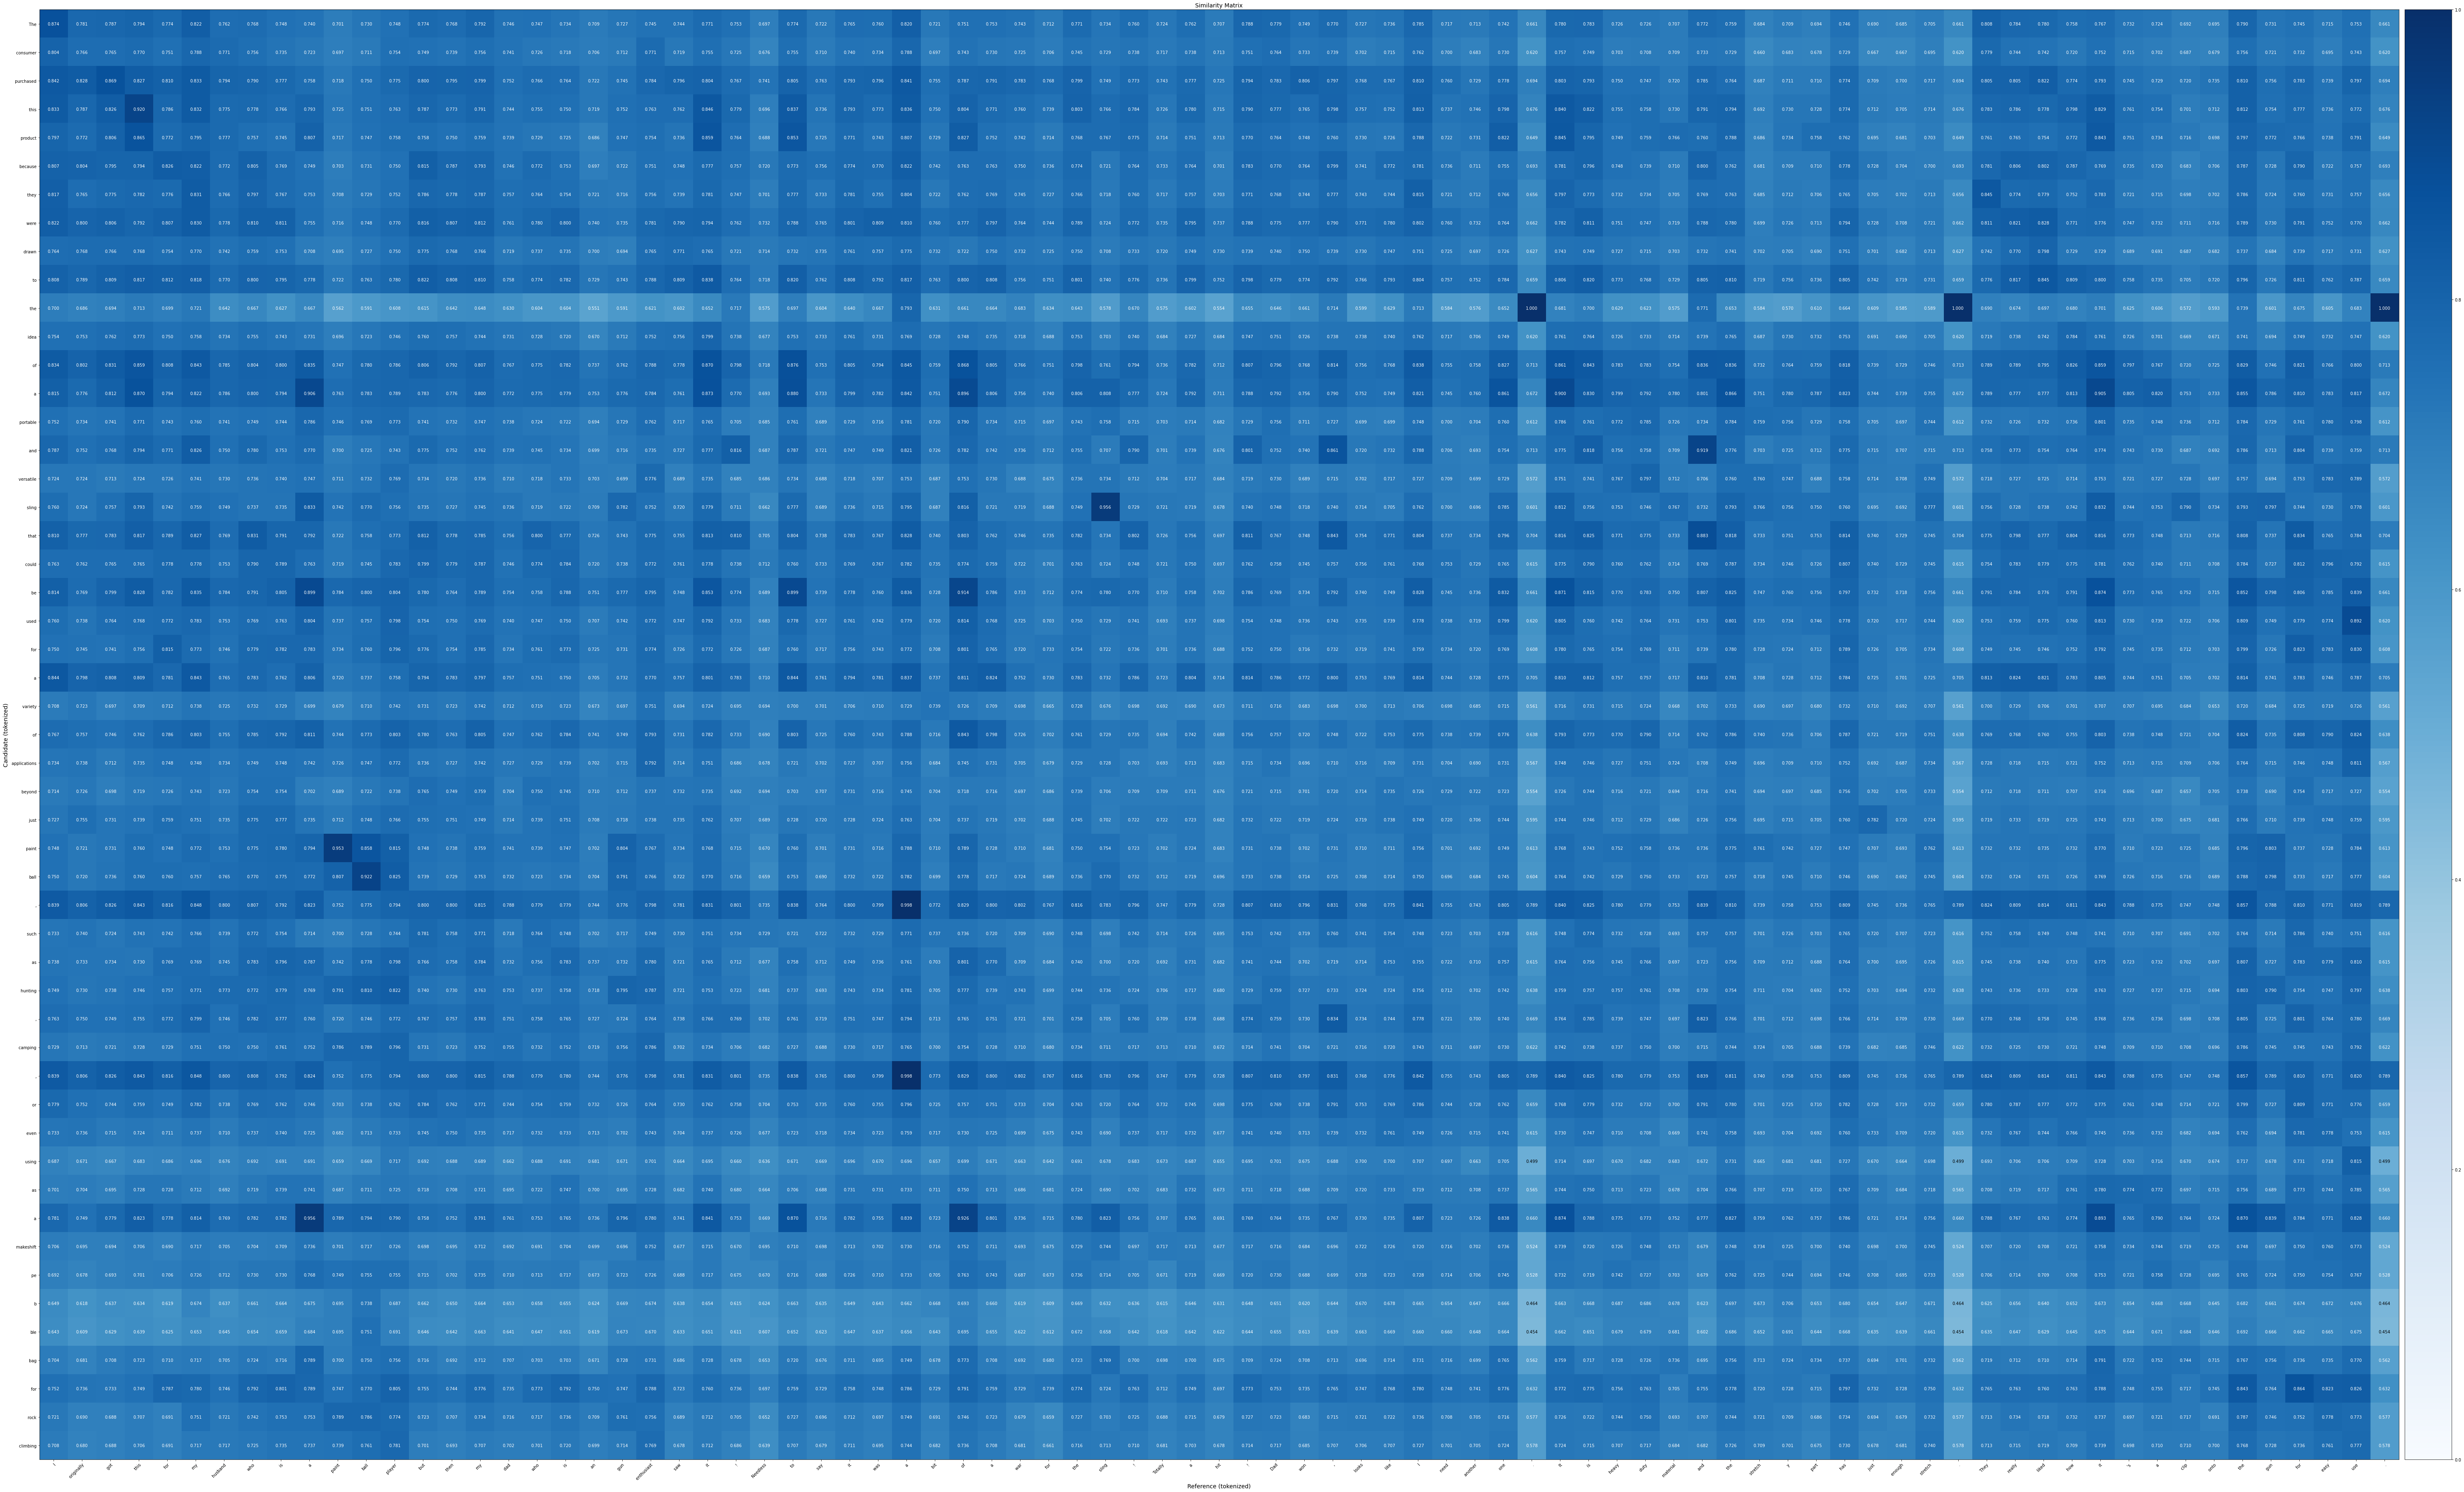

In [28]:
bert_score.plot_example(expls_all[pair]['pos-expl'],expls_all[pair]['reviewText'],lang='en')

In [29]:
bert_score.score([expls_all[pair]['neg-expl']],[expls_all[pair]['reviewText']],lang='en')

(tensor([0.8371]), tensor([0.8250]), tensor([0.8310]))

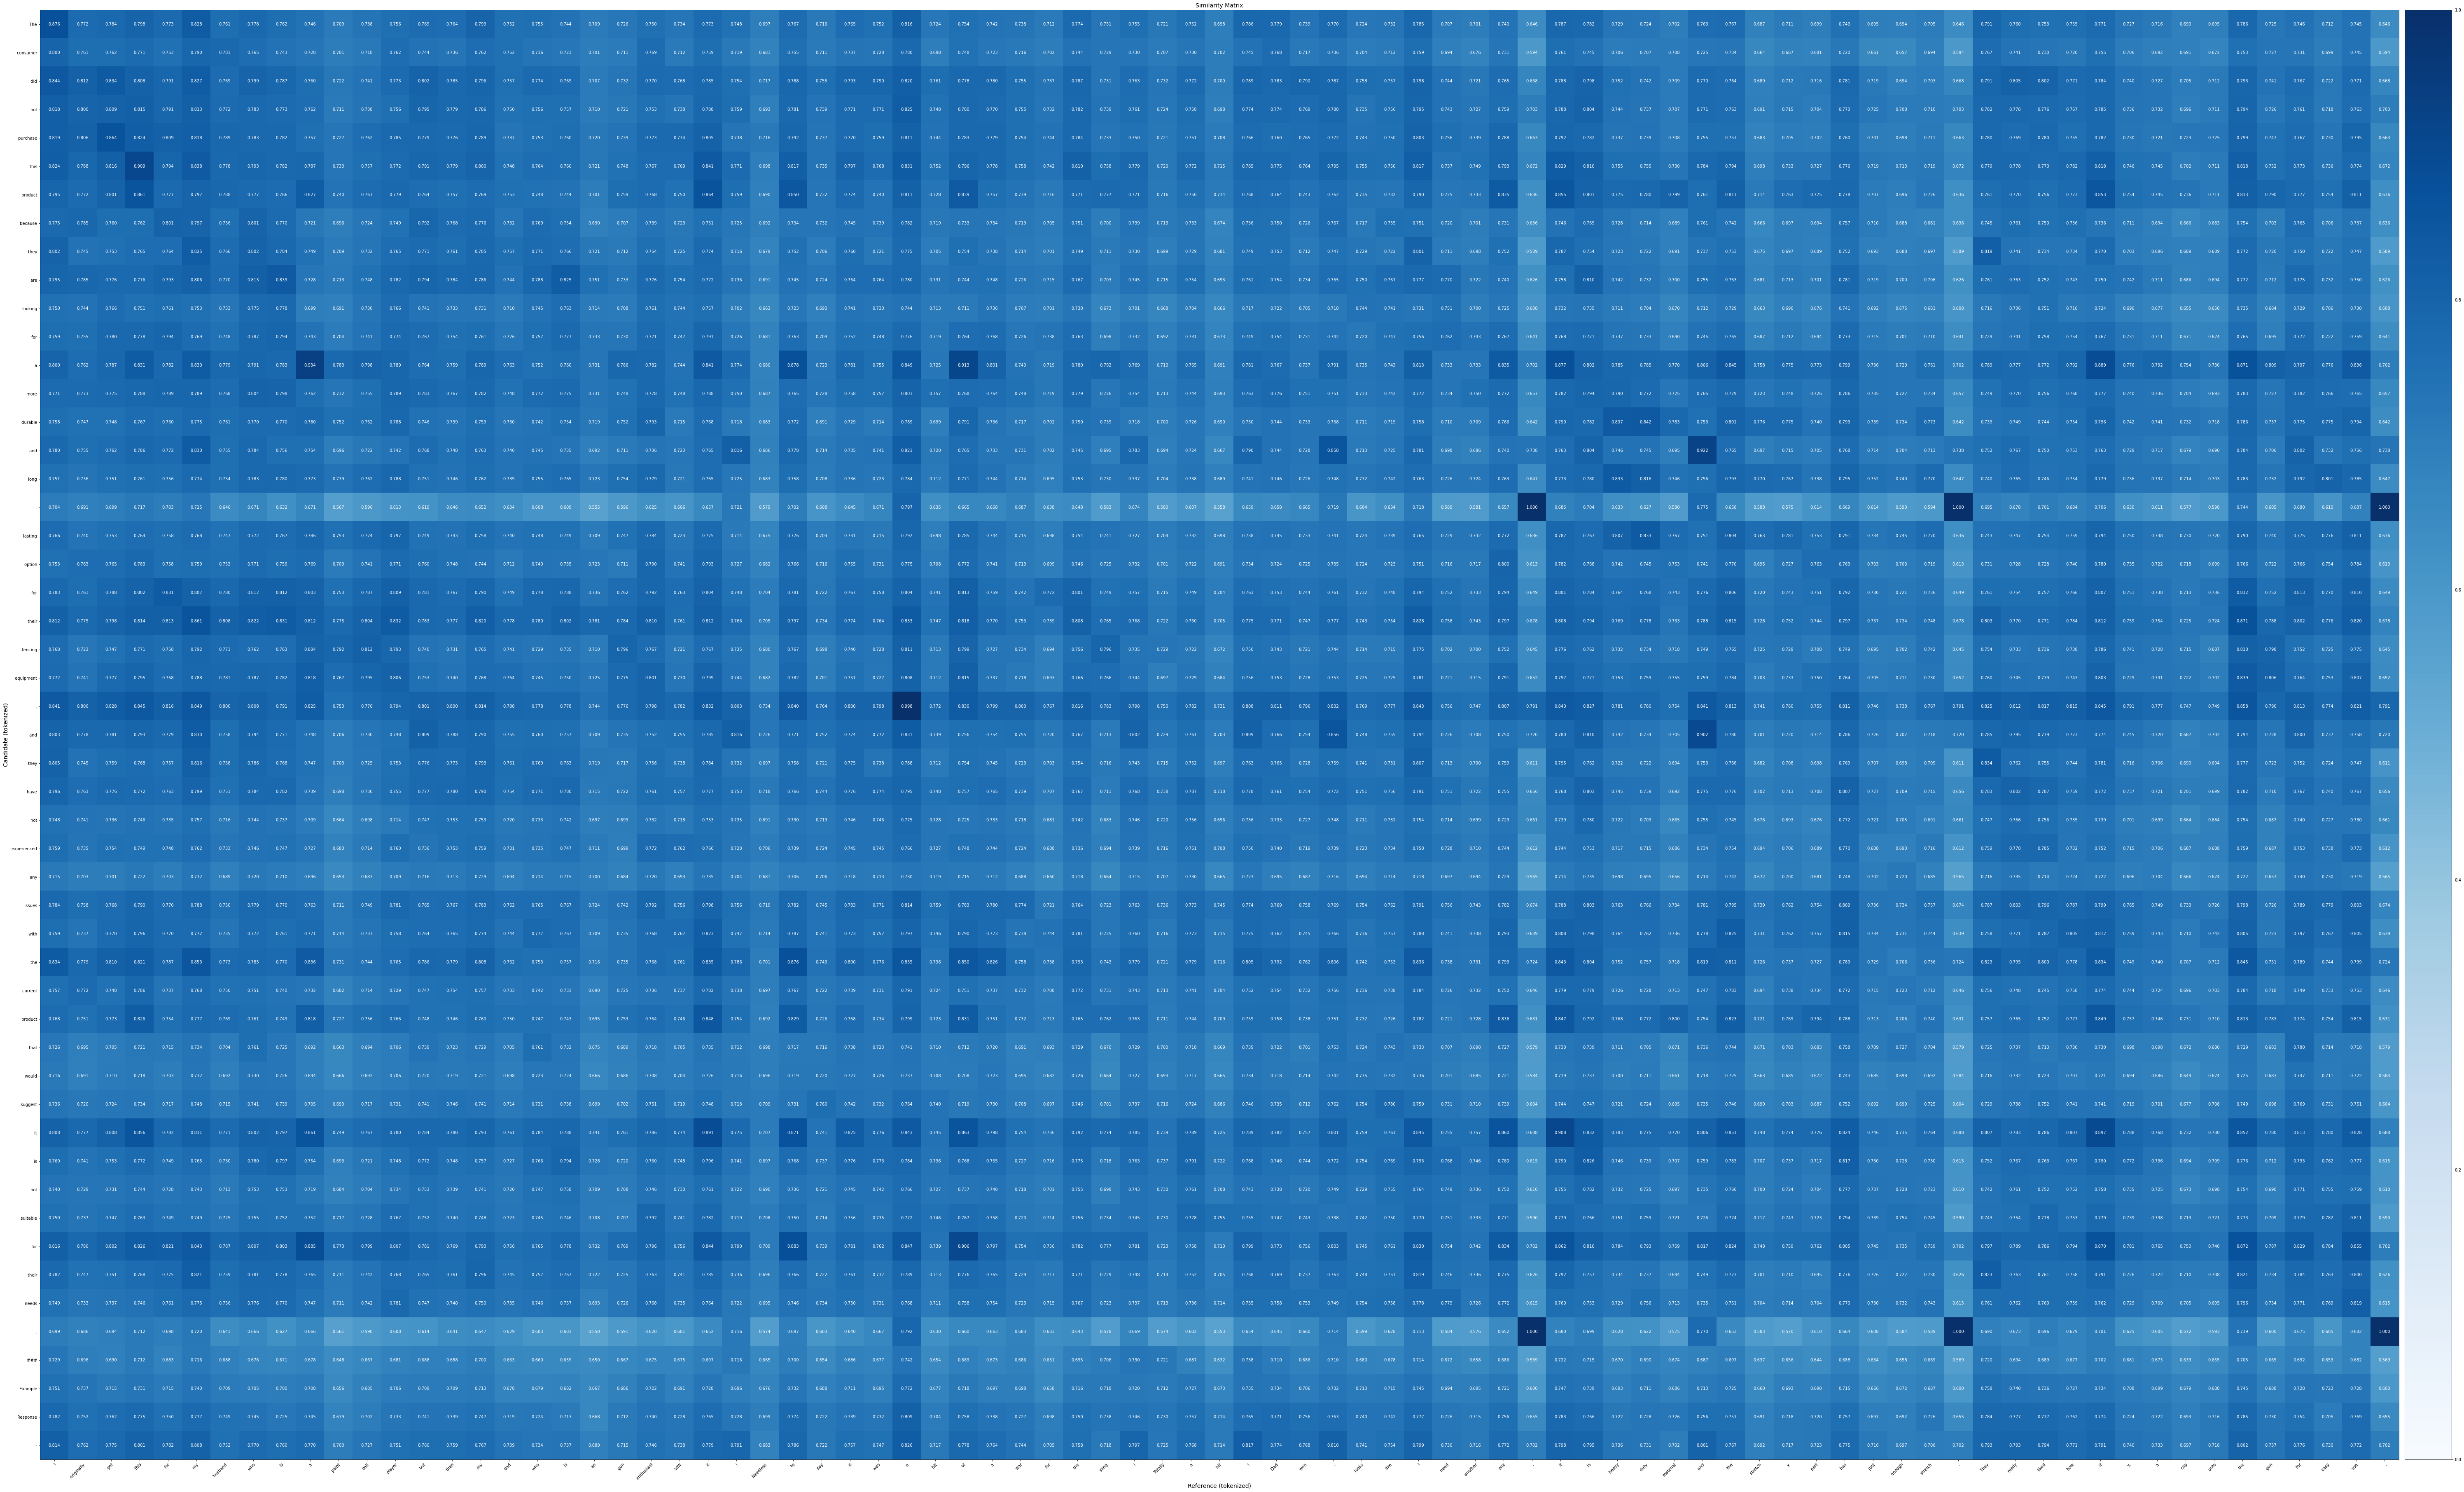

In [30]:
bert_score.plot_example(expls_all[pair]['neg-expl'],expls_all[pair]['reviewText'],lang='en')

# Evaluate

In [31]:
# ---------------------------------------------------------
# Helper function to print stats
# ---------------------------------------------------------
def bootstrap_ci(arr, num_samples=1000, ci=0.95):
    arr = np.array(arr)
    n = len(arr)
    boot_means = []

    for _ in range(num_samples):
        sample = np.random.choice(arr, size=n, replace=True)
        boot_means.append(sample.mean())

    lower = np.percentile(boot_means, (1-ci)*50)
    upper = np.percentile(boot_means, 100 - (1-ci)*50)
    return lower, upper


def print_stats(name, arr, threshold=None):
    print(f"\n{name} statistics:")
    print("  Count:", len(arr))
    print("  Mean:", arr.mean())
    print("  Std:", arr.std())
    print("  Median:", np.median(arr))
    # 95% CI
    lower, upper = bootstrap_ci(arr)
    print(f"  95% CI: [{lower:.4f}, {upper:.4f}]")

    if threshold is not None:
        print(f"  Low-quality (<{threshold}):", (arr < threshold).mean() * 100, "%")


def evaluate(val_data,col):
    # val_data <-- your validation dictionary
    print(f"Column: {col}")
    scorer = BERTScorer(lang="en")


    P_scores = []
    R_scores = []
    F1_scores = []

    # ---------------------------------------------------------
    # Iterate through validation samples
    # ---------------------------------------------------------
    for i, (key, sample) in tqdm(enumerate(list(val_data.items()))):
#         if i >=5:
#             break

        pos_expl = sample[col]
        gold_review = sample['reviewText']

        # Safety checks
        if not isinstance(pos_expl, str) or not isinstance(gold_review, str):
            continue
        if len(gold_review.strip()) == 0:
            continue

        # ---------------------------------------------------------
        # Compute BERTScore Precision, Recall, F1
        # ---------------------------------------------------------
        P, R, F1 = scorer.score([pos_expl], [gold_review])

        P_scores.append(float(P))
        R_scores.append(float(R))
        F1_scores.append(float(F1))


    # ---------------------------------------------------------
    # Convert to numpy arrays
    # ---------------------------------------------------------
    P_scores  = np.array(P_scores)
    R_scores  = np.array(R_scores)
    F1_scores = np.array(F1_scores)
    print_stats("Precision", P_scores)
    print_stats("Recall",    R_scores)
    print_stats("F1",        F1_scores, threshold=0.45)
    return {"P_scores":P_scores, "R_scores":R_scores, "F1_scores":F1_scores}

In [32]:
positive_metrics = evaluate(expls_all,'pos-expl')

Column: pos-expl


35598it [07:09, 82.96it/s] 



Precision statistics:
  Count: 35588
  Mean: 0.8418761488476053
  Std: 0.017623651049403274
  Median: 0.8427512049674988
  95% CI: [0.8417, 0.8421]

Recall statistics:
  Count: 35588
  Mean: 0.8307264733863196
  Std: 0.021720569881375818
  Median: 0.8323324620723724
  95% CI: [0.8305, 0.8309]

F1 statistics:
  Count: 35588
  Mean: 0.8360842842894671
  Std: 0.015663311043813976
  Median: 0.8365062177181244
  95% CI: [0.8359, 0.8362]
  Low-quality (<0.45): 0.0 %


In [33]:
negative_metrics = evaluate(expls_all,'neg-expl')

Column: neg-expl


35598it [07:04, 83.79it/s] 



Precision statistics:
  Count: 35588
  Mean: 0.8357379377956831
  Std: 0.016103868093180478
  Median: 0.8368448615074158
  95% CI: [0.8356, 0.8359]

Recall statistics:
  Count: 35588
  Mean: 0.8267569758121092
  Std: 0.02107034438290205
  Median: 0.8283727765083313
  95% CI: [0.8265, 0.8270]

F1 statistics:
  Count: 35588
  Mean: 0.8310611258484184
  Std: 0.014869112675812262
  Median: 0.8316262066364288
  95% CI: [0.8309, 0.8312]
  Low-quality (<0.45): 0.0 %


In [34]:
empty_pair = [pair for pair,sample in expls_all.items() if not isinstance(sample['reviewText'], str)]
empty_pair

[]

In [35]:
empty_pair = [sample for pair,sample in expls_all.items() if len(sample['reviewText'].strip()) == 0]
empty_pair

[{'pos-expl': 'The consumer purchased the Petzl Tikka Improved Lumen Output Plus 2 Headlamp because they are looking for a reliable backup light source for their outdoor adventures, particularly for hiking and backpacking excursions.',
  'neg-expl': 'The consumer did not purchase this product because they are looking for a gym bag instead.',
  'label': 1,
  'target_item': '"Petzl Tikka Improved Lumen Output Plus 2 Headlamp"',
  'reviewerID': 'A34EXL9TUB0XER',
  'asin': 'B009064MHW',
  'reviewerName': 'Eric C',
  'helpful': [35, 37],
  'reviewText': '',
  'overall': 5.0,
  'summary': 'Better & Improved, a Stellar Headlamp',
  'unixReviewTime': 1358035200,
  'reviewTime': '01 13, 2013',
  'related': {'also_bought': ['B002M9DXH4',
    'B009M65V98',
    'B009M66F3Y',
    'B002BWQ4H8',
    'B0099LSYVI',
    'B001E7S5BO',
    'B00HQNU95U',
    'B001LF3FR8',
    'B002PWFSHG',
    'B007N5YRY0',
    'B000OPPAQK',
    'B00CHHNQVY',
    'B00FHRADQ2',
    'B0009QFS5W',
    'B00EJP43FA',
    'B004D

In [36]:
empty_pair = [pair for pair,sample in expls_all.items() if not isinstance(sample['pos-expl'], str)]
empty_pair

[]

In [37]:
empty_pair = [pair for pair,sample in expls_all.items() if not isinstance(sample['neg-expl'], str)]
empty_pair

[]